# Course Project Checkpoint 1: Dataset Selection and EDA (GraphDancer Track)

**Student:** Leopold  
**Date:** 2026-02-10  
**Checkpoint scope:** dataset identification, comparative analysis, dataset selection, EDA, initial insights, GitHub portfolio setup.

## Why this notebook exists
I want to turn my GraphDancer paper direction into the semester project. This notebook completes the first checkpoint end-to-end and documents every major algorithmic choice with explicit rationale.


## Decision Protocol (used throughout)
For each technical choice, I explicitly answer **WHY**:
1. Why this data source and not alternatives.
2. Why this preprocessing is sufficient for a checkpoint-stage EDA.
3. Why this metric/visual helps shape project direction.
4. Why this selected dataset best supports both course and beyond-course techniques.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import gzip
import re
import subprocess
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_colwidth", 180)

# Resolve project root robustly, regardless of where the notebook is executed.
cwd = Path.cwd()
if (cwd / "data" / "raw").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "raw").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate project root containing data/raw")

DATA_ROOT = PROJECT_ROOT / "data" / "raw"
REPORT_ROOT = PROJECT_ROOT / "reports"
FIG_ROOT = REPORT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")


Project root: /Users/leopold/Documents/GraphDancerSlides/course_project_checkpoint1
Data root: /Users/leopold/Documents/GraphDancerSlides/course_project_checkpoint1/data/raw


## (A) Identification of Candidate Datasets

I use three candidates (including GRBench, as required by project intent):
1. **GRBench** (graph-augmented QA benchmark; selected candidate for deep EDA).
2. **ogbn-arxiv** (citation graph benchmark from Open Graph Benchmark).
3. **SNAP com-Amazon** (product co-purchasing graph).

**Why this trio:** all three support core course graph-mining topics, but each also offers a distinct beyond-course path (tool-using LLM agents, GNNs/Graph Transformers, and large-scale graph representation learning).


In [2]:
profiles = json.loads((REPORT_ROOT / "dataset_profiles.json").read_text(encoding="utf-8"))

candidate_rows = [
    {
        "Dataset": "GRBench",
        "Source": "https://huggingface.co/datasets/PeterJinGo/GRBench",
        "Course Topic Alignment": "Graph mining + text mining over external knowledge graphs",
        "Beyond-Course Technique(s)": "Graph-aware RL for tool-using LLM agents; trajectory-level policy optimization",
        "Dataset Size & Structure": f"{profiles['grbench']['total_samples']} QA samples across {profiles['grbench']['domains']} domain files (JSONL)",
        "Data Types": "domain, qid, question (text), answer (text), level (easy/medium/hard)",
        "Target Variable(s)": "Reference answer text (generative QA target)",
        "Licensing / Usage Constraints": "Apache-2.0 on HF dataset card",
    },
    {
        "Dataset": "ogbn-arxiv",
        "Source": "https://ogb.stanford.edu/docs/nodeprop/",
        "Course Topic Alignment": "Graph analytics, node classification, centrality/community-aware analysis",
        "Beyond-Course Technique(s)": "GNNs (GCN/GraphSAGE/GAT), graph transformers, self-supervised graph pretraining",
        "Dataset Size & Structure": f"{profiles['ogbn_arxiv']['nodes']:,} nodes, {profiles['ogbn_arxiv']['edges']:,} edges, {profiles['ogbn_arxiv']['feature_dim']}-dim node features",
        "Data Types": "edge list, node feature vectors, node year, node labels, temporal split",
        "Target Variable(s)": "arXiv category label (node classification)",
        "Licensing / Usage Constraints": "OGB benchmark terms + source dataset citation requirements",
    },
    {
        "Dataset": "SNAP com-Amazon",
        "Source": "https://snap.stanford.edu/data/com-Amazon.html",
        "Course Topic Alignment": "Graph mining, community discovery, graph statistics",
        "Beyond-Course Technique(s)": "Node2Vec/DeepWalk embeddings, scalable link prediction, graph representation learning",
        "Dataset Size & Structure": f"{profiles['snap_com_amazon']['nodes']:,} nodes, {profiles['snap_com_amazon']['edges']:,} undirected edges (edge list)",
        "Data Types": "from-node ID, to-node ID (unattributed graph)",
        "Target Variable(s)": "No direct label (unsupervised/structural tasks)",
        "Licensing / Usage Constraints": "SNAP data usage/citation norms (research/benchmark usage)",
    },
]

candidate_df = pd.DataFrame(candidate_rows)
candidate_df


,Dataset,Source,Course Topic Alignment,Beyond-Course Technique(s),Dataset Size & Structure,Data Types,Target Variable(s),Licensing / Usage Constraints
0,GRBench,https://huggingface.co/datasets/PeterJinGo/GRBench,Graph mining + text mining over external knowledge graphs,Graph-aware RL for tool-using LLM agents; trajectory-level policy optimization,1740 QA samples across 10 domain files (JSONL),"domain, qid, question (text), answer (text), level (easy/medium/hard)",Reference answer text (generative QA target),Apache-2.0 on HF dataset card
1,ogbn-arxiv,https://ogb.stanford.edu/docs/nodeprop/,"Graph analytics, node classification, centrality/community-aware analysis","GNNs (GCN/GraphSAGE/GAT), graph transformers, self-supervised graph pretraining","169,343 nodes, 1,166,243 edges, 128-dim node features","edge list, node feature vectors, node year, node labels, temporal split",arXiv category label (node classification),OGB benchmark terms + source dataset citation requirements
2,SNAP com-Amazon,https://snap.stanford.edu/data/com-Amazon.html,"Graph mining, community discovery, graph statistics","Node2Vec/DeepWalk embeddings, scalable link prediction, graph representation learning","334,863 nodes, 925,872 undirected edges (edge list)","from-node ID, to-node ID (unattributed graph)",No direct label (unsupervised/structural tasks),SNAP data usage/citation norms (research/benchmark usage)


### Candidate Summary Notes
- **GRBench** is the strongest conceptual bridge from my GraphDancer paper to the class project.
- **ogbn-arxiv** is a robust fallback with mature baselines and reproducible splits.
- **com-Amazon** is computationally feasible while still large enough for realistic graph mining constraints.


## (B) Comparative Analysis of Datasets

**Algorithmic decision:** I compare along exactly the required rubric dimensions, because these dimensions determine not only feasibility but project risk (data quality, bias, ethics).


In [3]:
comparison_rows = [
    {
        "Dataset": "GRBench",
        "Supported Data Mining Tasks": "Course: graph/text reasoning over graph-structured knowledge. External: graph-aware RL for tool trajectories.",
        "Data Quality Issues": "Long-tail domain heterogeneity; mixed answer lengths; possible annotation inconsistency across domains.",
        "Algorithmic Feasibility": "High for checkpoint EDA (small-to-medium size); moderate for full RL training.",
        "Bias Considerations": "Domain imbalance (e.g., healthcare/literature larger than some science domains); prompt-style bias.",
        "Ethical Considerations": "Legal/medical QA may produce overconfident incorrect answers if used without human oversight.",
    },
    {
        "Dataset": "ogbn-arxiv",
        "Supported Data Mining Tasks": "Course: graph mining + node classification. External: GNN/Graph Transformer and temporal graph learning.",
        "Data Quality Issues": "Citation graph incompleteness, noisy labels, temporal shift between train/test splits.",
        "Algorithmic Feasibility": "Feasible on a laptop for sampling/baselines; full model sweeps need careful resource control.",
        "Bias Considerations": "Field/time imbalance can bias predictions toward dominant subfields and eras.",
        "Ethical Considerations": "Potentially amplifies historical publication inequities in academic visibility.",
    },
    {
        "Dataset": "SNAP com-Amazon",
        "Supported Data Mining Tasks": "Course: graph statistics, centrality, community detection. External: node embeddings/link prediction.",
        "Data Quality Issues": "No node attributes, no labels, historical snapshot limits temporal validity.",
        "Algorithmic Feasibility": "Highly feasible for classical graph methods; representation learning feasible with mini-batching.",
        "Bias Considerations": "Commercial co-purchase graph can embed popularity and exposure bias.",
        "Ethical Considerations": "Recommendation-style analysis can reinforce feedback loops and market concentration.",
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Dataset,Supported Data Mining Tasks,Data Quality Issues,Algorithmic Feasibility,Bias Considerations,Ethical Considerations
0,GRBench,Course: graph/text reasoning over graph-structured knowledge. External: graph-aware RL for tool trajectories.,Long-tail domain heterogeneity; mixed answer lengths; possible annotation inconsistency across domains.,High for checkpoint EDA (small-to-medium size); moderate for full RL training.,"Domain imbalance (e.g., healthcare/literature larger than some science domains); prompt-style bias.",Legal/medical QA may produce overconfident incorrect answers if used without human oversight.
1,ogbn-arxiv,Course: graph mining + node classification. External: GNN/Graph Transformer and temporal graph learning.,"Citation graph incompleteness, noisy labels, temporal shift between train/test splits.",Feasible on a laptop for sampling/baselines; full model sweeps need careful resource control.,Field/time imbalance can bias predictions toward dominant subfields and eras.,Potentially amplifies historical publication inequities in academic visibility.
2,SNAP com-Amazon,"Course: graph statistics, centrality, community detection. External: node embeddings/link prediction.","No node attributes, no labels, historical snapshot limits temporal validity.",Highly feasible for classical graph methods; representation learning feasible with mini-batching.,Commercial co-purchase graph can embed popularity and exposure bias.,Recommendation-style analysis can reinforce feedback loops and market concentration.


## (C) Dataset Selection

**Decision rationale:** use a lightweight weighted score for transparency, then confirm with qualitative trade-off analysis.

Scoring criteria:
- GraphDancer fit (weight 0.35)
- Course-technique coverage (0.20)
- Beyond-course novelty (0.25)
- Data access + reproducibility for this semester (0.20)


In [4]:
weights = {
    "graphdancer_fit": 0.35,
    "course_coverage": 0.20,
    "beyond_novelty": 0.25,
    "reproducibility": 0.20,
}

# Scores are 1-5 and intentionally conservative.
score_rows = [
    {"Dataset": "GRBench", "graphdancer_fit": 5, "course_coverage": 4, "beyond_novelty": 5, "reproducibility": 4},
    {"Dataset": "ogbn-arxiv", "graphdancer_fit": 3, "course_coverage": 5, "beyond_novelty": 4, "reproducibility": 5},
    {"Dataset": "SNAP com-Amazon", "graphdancer_fit": 3, "course_coverage": 4, "beyond_novelty": 4, "reproducibility": 5},
]
score_df = pd.DataFrame(score_rows)
score_df["weighted_score"] = sum(score_df[c] * w for c, w in weights.items())
score_df = score_df.sort_values("weighted_score", ascending=False).reset_index(drop=True)
score_df


,Dataset,graphdancer_fit,course_coverage,beyond_novelty,reproducibility,weighted_score
0,GRBench,5,4,5,4,4.60
1,ogbn-arxiv,3,5,4,5,4.05
2,SNAP com-Amazon,3,4,4,5,3.85


### Selected Dataset: **GRBench**

**Why selected:**
- Direct continuity with my GraphDancer research direction.
- Naturally supports course graph/text mining themes.
- Enables at least one clearly beyond-course method: graph-aware RL for multi-round tool-use trajectories.

**Trade-offs accepted:**
- Smaller total sample size than some industrial graph datasets.
- QA-focused supervision means fewer classic node-label tasks.
- Needs careful handling of domain and difficulty imbalance.


## (D) Exploratory Data Analysis (Selected Dataset Only: GRBench)

**Algorithmic decision:** parse JSONL directly (not schema inference tools) to keep preprocessing deterministic and auditable.


In [5]:
def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

records = []
for path in sorted((DATA_ROOT / "grbench").glob("*.json")):
    domain = path.stem
    for row in read_jsonl(path):
        records.append(
            {
                "domain": domain,
                "qid": str(row.get("qid", "")).strip(),
                "question": str(row.get("question", "")).strip(),
                "answer": str(row.get("answer", "")).strip(),
                "level": str(row.get("level", "")).strip().lower(),
            }
        )

df_raw = pd.DataFrame(records)

# Cleaning choices:
# 1) trim text whitespace,
# 2) standardize level labels,
# 3) remove exact duplicate rows (if any).
expected_levels = {"easy", "medium", "hard"}

df_clean = df_raw.copy()
df_clean["level"] = df_clean["level"].replace({"": "unknown"})
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Feature engineering for EDA (word lengths are interpretable and robust).
df_clean["question_len_words"] = df_clean["question"].str.split().str.len()
df_clean["answer_len_words"] = df_clean["answer"].str.split().str.len()

# Validation tests (non-trivial behavior checks).
assert df_clean["question"].eq("").sum() == 0, "Empty questions found"
assert df_clean["answer"].eq("").sum() == 0, "Empty answers found"
assert df_clean.duplicated(subset=["domain", "qid"]).sum() == 0, "Duplicate qid within domain found"
assert set(df_clean["level"].unique()).issubset(expected_levels), "Unexpected level labels detected"

print(df_clean.shape)
df_clean.head()


(1740, 7)


,domain,qid,question,answer,level,question_len_words,answer_len_words
0,amazon,0,Could you specify the brand of Dolica DC-BP511 1400mAh Canon Battery?,Dolica,easy,11,1
1,amazon,1,Could you specify the brand of [Aftermarket Product] Black PU Leather Wireless Bluetooth Keyboard Flip Case Cover For Samsung Galaxy S3 i9300 Sprint L710 att i747 Verizon i535 ...,Best Match,easy,31,2
2,amazon,2,Could you specify the brand of Blackberry Playbook 7-Inch Tablet (64GB)?,BlackBerry,easy,11,1
3,amazon,3,What brand does the item Intermatic ML900TW 900-Watt Power Pack with Timer and Ground Shield belong to?,Intermatic,easy,17,1
4,amazon,4,What is the brand of item Easy Provider Covert Acoustic Tube Earpiece 2 PIN for Motorola Radio?,Epower Mall,easy,17,2


In [6]:
summary_table = pd.DataFrame(
    {
        "metric": [
            "total_samples",
            "num_domains",
            "num_levels",
            "missing_questions",
            "missing_answers",
            "duplicate_(domain,qid)",
            "avg_question_words",
            "avg_answer_words",
            "max_question_words",
            "max_answer_words",
        ],
        "value": [
            len(df_clean),
            df_clean["domain"].nunique(),
            df_clean["level"].nunique(),
            int(df_clean["question"].isna().sum()),
            int(df_clean["answer"].isna().sum()),
            int(df_clean.duplicated(subset=["domain", "qid"]).sum()),
            round(float(df_clean["question_len_words"].mean()), 2),
            round(float(df_clean["answer_len_words"].mean()), 2),
            int(df_clean["question_len_words"].max()),
            int(df_clean["answer_len_words"].max()),
        ],
    }
)
summary_table


,metric,value
0,total_samples,1740.00
1,num_domains,10.00
2,num_levels,3.00
3,missing_questions,0.00
4,missing_answers,0.00
5,"duplicate_(domain,qid)",0.00
6,avg_question_words,30.69
7,avg_answer_words,5.76
8,max_question_words,250.00
9,max_answer_words,362.00


/var/folders/vw/q1hc06sj60l9hdrdh0ql85sc0000gn/T/ipykernel_45277/573805820.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="level", order=["easy", "medium", "hard"], ax=axes[1], palette="Set2")


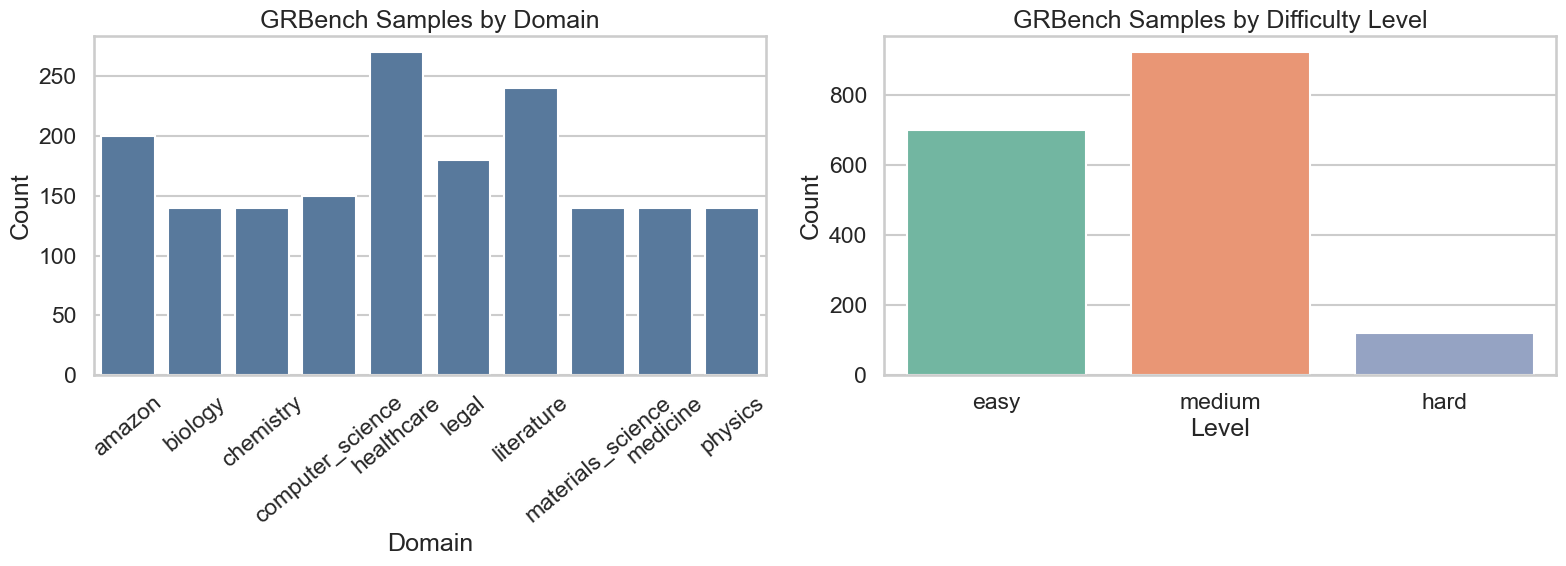

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_clean, x="domain", order=sorted(df_clean["domain"].unique()), ax=axes[0], color="#4C78A8")
axes[0].set_title("GRBench Samples by Domain")
axes[0].set_xlabel("Domain")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=40)

sns.countplot(data=df_clean, x="level", order=["easy", "medium", "hard"], ax=axes[1], palette="Set2")
axes[1].set_title("GRBench Samples by Difficulty Level")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Count")

fig.tight_layout()
fig.savefig(FIG_ROOT / "grbench_domain_level_counts.png", dpi=180, bbox_inches="tight")
plt.show()


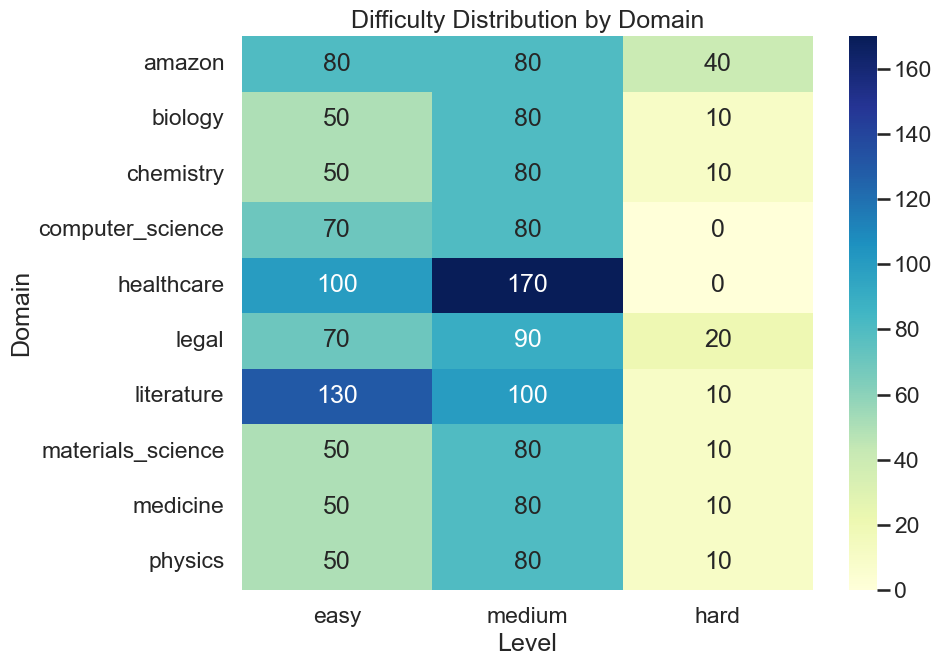

level,easy,medium,hard
domain,,,
amazon,80,80,40
biology,50,80,10
chemistry,50,80,10
computer_science,70,80,0
healthcare,100,170,0
legal,70,90,20
literature,130,100,10
materials_science,50,80,10
medicine,50,80,10


In [8]:
pivot = pd.crosstab(df_clean["domain"], df_clean["level"]).reindex(columns=["easy", "medium", "hard"], fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Difficulty Distribution by Domain")
ax.set_xlabel("Level")
ax.set_ylabel("Domain")
fig.tight_layout()
fig.savefig(FIG_ROOT / "grbench_domain_level_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
pivot


/var/folders/vw/q1hc06sj60l9hdrdh0ql85sc0000gn/T/ipykernel_45277/1033134257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="level", y="question_len_words", order=["easy", "medium", "hard"], ax=axes[0], palette="Set3")
/var/folders/vw/q1hc06sj60l9hdrdh0ql85sc0000gn/T/ipykernel_45277/1033134257.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="level", y="answer_len_words", order=["easy", "medium", "hard"], ax=axes[1], palette="Set1")


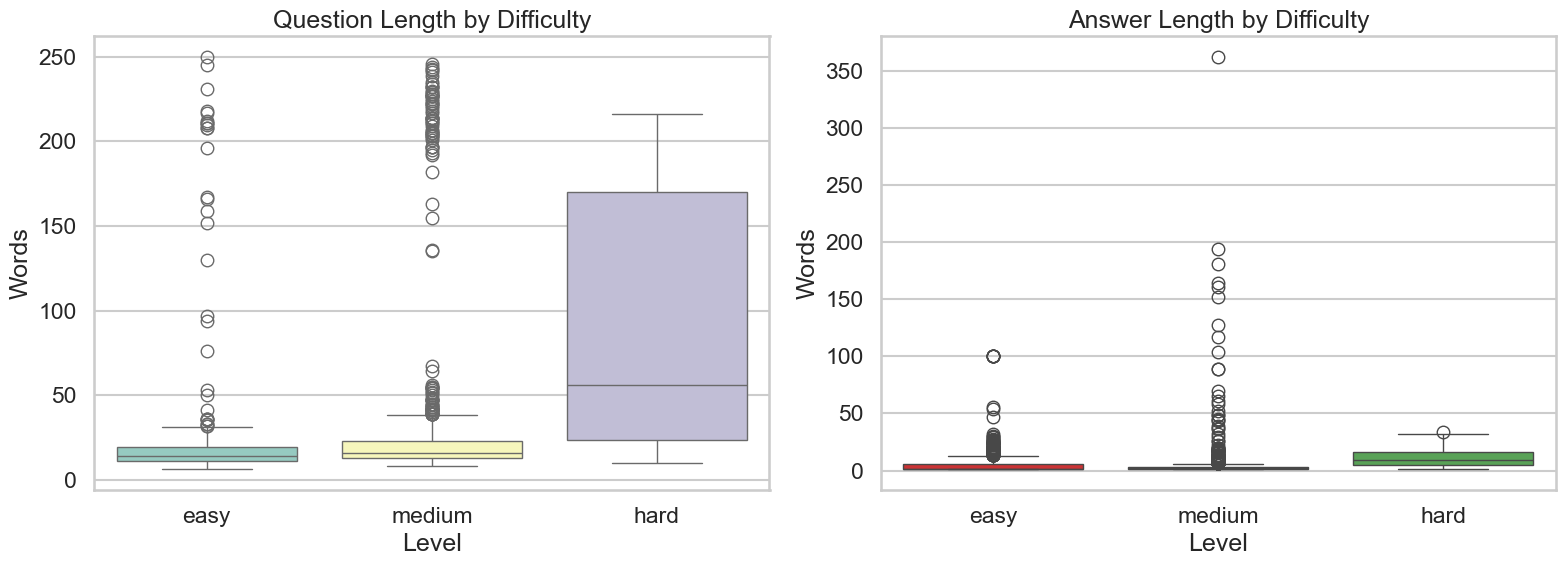

,question_len_words,answer_len_words
level,,
easy,20.25,5.36
hard,90.82,10.83
medium,30.79,5.40


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_clean, x="level", y="question_len_words", order=["easy", "medium", "hard"], ax=axes[0], palette="Set3")
axes[0].set_title("Question Length by Difficulty")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Words")

sns.boxplot(data=df_clean, x="level", y="answer_len_words", order=["easy", "medium", "hard"], ax=axes[1], palette="Set1")
axes[1].set_title("Answer Length by Difficulty")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Words")

fig.tight_layout()
fig.savefig(FIG_ROOT / "grbench_length_by_level.png", dpi=180, bbox_inches="tight")
plt.show()

df_clean.groupby("level")[["question_len_words", "answer_len_words"]].mean().round(2)


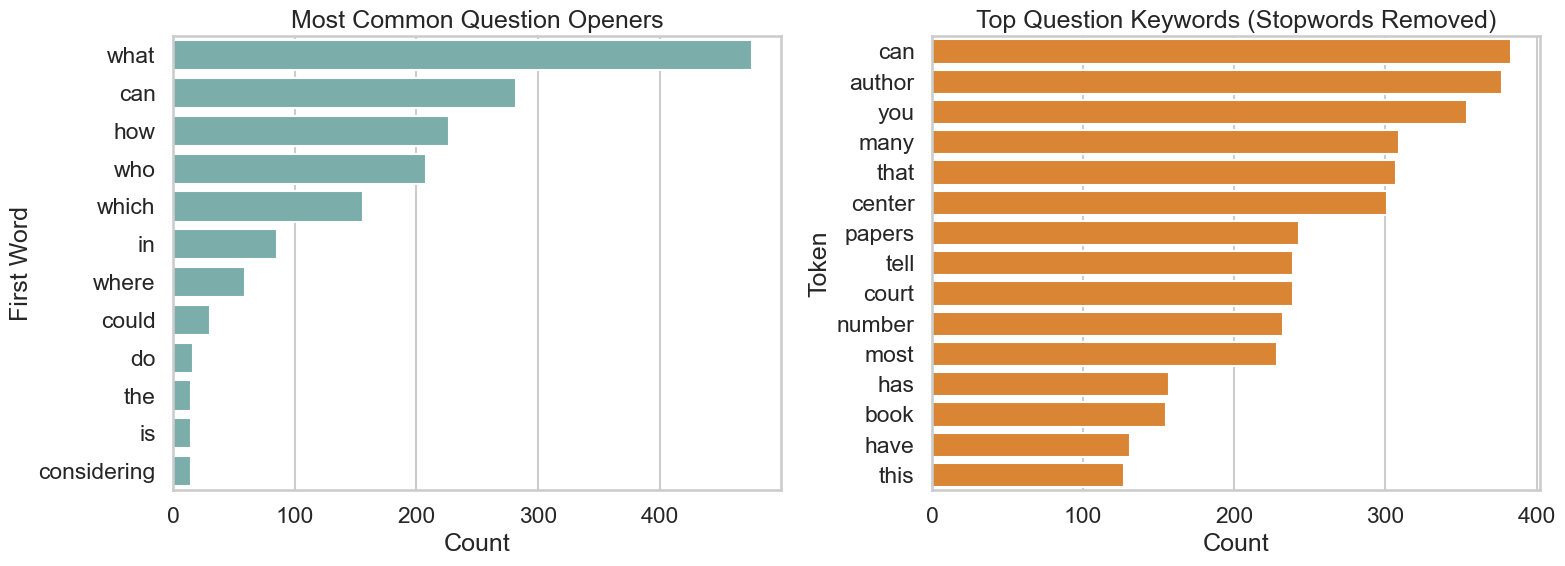

(question
 what           476
 can            282
 how            227
 who            208
 which          156
 in              85
 where           59
 could           30
 do              16
 the             15
 is              15
 considering     15
 Name: count, dtype: int64,
     token  count
 0     can    383
 1  author    377
 2     you    354
 3    many    309
 4    that    307
 5  center    301
 6  papers    243
 7    tell    239
 8   court    239
 9  number    232)

In [10]:
# Lightweight lexical bias probe: question openers and keyword concentration.
def first_word(text: str) -> str:
    tokens = re.findall(r"[A-Za-z']+", text.lower())
    return tokens[0] if tokens else "<empty>"

openers = df_clean["question"].apply(first_word)
opener_counts = openers.value_counts().head(12)

stop = {
    "the", "a", "an", "is", "are", "of", "in", "on", "for", "with", "to", "and", "who",
    "what", "which", "where", "when", "how", "do", "did", "does", "be", "by", "from", "paper", "titled",
}
all_tokens = []
for q in df_clean["question"].str.lower():
    toks = re.findall(r"[a-z']+", q)
    all_tokens.extend([t for t in toks if t not in stop and len(t) > 2])

top_keywords = pd.DataFrame(Counter(all_tokens).most_common(15), columns=["token", "count"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=opener_counts.values, y=opener_counts.index, ax=axes[0], color="#72B7B2")
axes[0].set_title("Most Common Question Openers")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("First Word")

sns.barplot(data=top_keywords, x="count", y="token", ax=axes[1], color="#F58518")
axes[1].set_title("Top Question Keywords (Stopwords Removed)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Token")

fig.tight_layout()
fig.savefig(FIG_ROOT / "grbench_lexical_patterns.png", dpi=180, bbox_inches="tight")
plt.show()

opener_counts, top_keywords.head(10)


In [11]:
# Bias + feasibility diagnostics to motivate next checkpoint methods.
bias_report = pd.DataFrame(
    {
        "metric": [
            "domain_imbalance_ratio(max/min)",
            "medium_level_share",
            "hard_level_share",
            "questions_starting_with_'who'",
            "answers_longer_than_20_words",
        ],
        "value": [
            round(df_clean["domain"].value_counts().max() / df_clean["domain"].value_counts().min(), 2),
            round((df_clean["level"] == "medium").mean(), 3),
            round((df_clean["level"] == "hard").mean(), 3),
            round(df_clean["question"].str.lower().str.contains(r"\bwho\b").mean(), 3),
            round((df_clean["answer_len_words"] > 20).mean(), 3),
        ],
    }
)
bias_report


,metric,value
0,domain_imbalance_ratio(max/min),1.930
1,medium_level_share,0.529
2,hard_level_share,0.069
3,questions_starting_with_'who',0.153
4,answers_longer_than_20_words,0.043


## (E) Initial Insights and Direction

### Initial observations
1. Domain sizes are imbalanced (notably larger healthcare and literature subsets), so naive aggregate metrics may hide weak-domain behavior.
2. Medium questions dominate, while hard questions are sparse; this can bias model tuning toward medium-difficulty performance.
3. Question and answer length distributions are heavy-tailed, suggesting robust handling of long outputs is necessary.
4. Lexical patterns show recurrent templates, which may inflate performance for prompt-matching strategies.

### Hypotheses for next checkpoint
1. Curriculum-style sampling by difficulty and domain will improve hard-sample robustness versus uniform sampling.
2. Trajectory-level evaluation (tool-call quality, evidence sufficiency) will reveal failure modes hidden by answer-only metrics.

### Potential research questions (RQs)
1. How much does domain-aware reweighting change hard-level accuracy/quality?
2. Does graph-aware RL improve trajectory efficiency versus prompting-only baselines on GRBench?
3. Which error types dominate in legal and healthcare domains under distribution shift?


## (F) GitHub Portfolio Building

- Public repository (to submit): `REPLACE_WITH_PUBLIC_GITHUB_LINK`
- First notebook: `notebooks/checkpoint1_graphdancer.ipynb`
- Supporting artifacts:
  - `scripts/download_datasets.py`
  - `reports/dataset_download_log.json`
  - `reports/dataset_profiles.json`
  - `reports/figures/*.png`

### README expectations
- Project motivation and scope.
- Candidate datasets + final selection rationale.
- Reproducible setup steps.
- Results snapshot and next checkpoint plan.


In [12]:
# Optional helper: print git remotes so the final report can include the public GitHub URL.
try:
    remotes = subprocess.check_output(["git", "remote", "-v"], cwd=PROJECT_ROOT, text=True)
    print(remotes if remotes.strip() else "No git remotes configured yet.")
except Exception as exc:
    print(f"Could not read git remotes: {exc}")


No git remotes configured yet.


## Collaboration Declaration

### (1) Collaborators
- None for this checkpoint.

### (2) Web Sources
- GRBench dataset card: https://huggingface.co/datasets/PeterJinGo/GRBench  
- GRBench dataset API metadata: https://huggingface.co/api/datasets/PeterJinGo/GRBench  
- OGB node property prediction docs: https://ogb.stanford.edu/docs/nodeprop/  
- OGB arxiv download endpoint: https://snap.stanford.edu/ogb/data/nodeproppred/arxiv.zip  
- SNAP com-Amazon page: https://snap.stanford.edu/data/com-Amazon.html  
- SNAP com-Amazon download endpoint: https://snap.stanford.edu/data/bigdata/communities/com-amazon.ungraph.txt.gz

### (3) AI Tools
- OpenAI Codex (GPT-5-based coding agent) for workflow automation, code generation, and notebook structuring.

### (4) Citations for Papers Used
- Jin, Y., et al. (2024). *Graph Chain-of-Thought: Augmenting Large Language Models by Reasoning on Graphs*.  
- Bai, Y., et al. (2026). *GraphDancer: A Graph-Aware Curriculum for Reinforcement Fine-Tuning in Graph-Augmented Reasoning*.  
- Hu, W., et al. (2020). *Open Graph Benchmark: Datasets for Machine Learning on Graphs*.
